# Apartment Rental Price Prediction — Canton Zurich

Iterative modeling notebook for the block1 exercise.  
**Target:** `price` (monthly rent in CHF)  
**Dataset:** `apartments_data_enriched_with_new_features.csv` (2,344 rows, 45 columns)

**New feature introduced:** `dist_to_nearest_station_km` — Haversine distance to the nearest of 15 major train stations in Canton Zurich.

In [1]:
import warnings
import pickle
from math import radians, sin, cos, sqrt, atan2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("Imports OK")

Imports OK


---
## 1. Data Loading & Preprocessing

In [2]:
df_raw = pd.read_csv("apartments_data_enriched_with_new_features.csv")
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)

Raw shape: (804, 45)


,Unnamed: 0,bfs_number,rooms,area,price,postalcode,address,town,description_raw,bfs_name,...,Kreis 10,Kreis 4,Kreis 1,Kreis 9,Kreis 5,Kreis 7,Kreis 3,Kreis 2,Kreis 8,zurich_city
0,0,118,3.0,49,1441,8630,"Neuhusstrasse 6, 8630 Rüti ZH",Rüti ZH,«Gemütliche Wohnung im Grünen»,Rüti (ZH),...,0,0,0,0,0,0,0,0,0,0
1,1,118,3.0,111,2600,8630,"Widacherstrasse 5, 8630 Rüti ZH",Rüti ZH,«3 Zimmer-Maisonette-Wohnung»,Rüti (ZH),...,0,0,0,0,0,0,0,0,0,0
2,2,118,3.0,58,1490,8630,"Widenweg 14, 8630 Rüti ZH",Rüti ZH,"«Ruhig & Grün , Genau was Sie suchen !»",Rüti (ZH),...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Features we will use across both iterations + coordinates needed for new feature
REQUIRED_COLS = [
    "rooms", "area", "pop", "pop_dens", "frg_pct", "emp", "tax_income",
    "room_per_m2", "luxurious", "temporary", "furnished",
    "area_cat_ecoded", "zurich_city",
    "lat", "lon", "price"
]

df = df_raw[REQUIRED_COLS].copy()
df = df.dropna()
df = df.drop_duplicates()
df = df.loc[(df["price"] >= 750) & (df["price"] <= 8000)].reset_index(drop=True)

print(f"After cleaning: {df.shape}")
print(f"Price range: CHF {df['price'].min():.0f} – CHF {df['price'].max():.0f}")
df.describe()

After cleaning: (802, 16)
Price range: CHF 750 – CHF 7900


,rooms,area,pop,pop_dens,frg_pct,emp,tax_income,room_per_m2,luxurious,temporary,furnished,area_cat_ecoded,zurich_city,lat,lon,price
count,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000,802.000000,802.00000,802.000000,802.000000,802.000000,802.000000
mean,3.375935,86.937656,38376.744389,2707.695112,28.557610,176027.785536,81635.586035,26.082855,0.006234,0.019950,0.018703,1.42394,0.324190,47.408075,8.598091,2570.628429
std,1.274647,38.489470,45742.042202,2213.063473,7.613365,222565.936373,14496.195764,9.159718,0.078761,0.139916,0.135559,0.72227,0.468363,0.081315,0.119817,1074.609939
min,1.000000,10.000000,789.000000,87.959866,7.547170,129.000000,65147.000000,10.000000,0.000000,0.000000,0.000000,0.00000,0.000000,47.195290,8.367630,750.000000
25%,2.500000,63.000000,10096.000000,1200.586265,24.535004,5001.250000,71575.000000,22.000000,0.000000,0.000000,0.000000,1.00000,0.000000,47.363220,8.515804,1830.000000
50%,3.500000,83.500000,24990.000000,1662.597326,28.865843,19226.000000,80977.000000,24.670000,0.000000,0.000000,0.000000,2.00000,0.000000,47.399876,8.564344,2362.500000
75%,4.500000,105.000000,41411.000000,3759.212880,32.458468,491193.000000,85446.000000,28.000000,0.000000,0.000000,0.000000,2.00000,1.000000,47.470931,8.710154,3000.000000
max,7.500000,282.000000,420217.000000,10008.000000,46.226483,491193.000000,193412.000000,163.000000,1.000000,1.000000,1.000000,2.00000,1.000000,47.693893,8.915933,7900.000000


---
## 2. New Feature Engineering: Distance to Nearest Train Station

The new feature `dist_to_nearest_station_km` captures **transit proximity**, a key driver of rental prices in Switzerland.  
It is computed as the Haversine distance from each apartment's GPS coordinates to the nearest of 15 major S-Bahn / intercity stations in Canton Zurich.

**Why this feature?**  
The existing demographic features (population density, tax income, etc.) capture area-level socioeconomic context, but do not encode micro-level transit access. An apartment 300m from a train station typically rents for more than an equivalent one 3km away.

In [4]:
# 15 major train stations in Canton Zurich (name, lat, lon)
STATIONS = [
    ("Zürich HB",       47.3779, 8.5403),
    ("Winterthur",      47.5001, 8.7238),
    ("Uster",           47.3472, 8.7178),
    ("Bülach",          47.5214, 8.5363),
    ("Dietikon",        47.4023, 8.3993),
    ("Wädenswil",       47.2231, 8.6751),
    ("Thalwil",         47.2920, 8.5671),
    ("Kloten",          47.4510, 8.5869),
    ("Dübendorf",       47.3959, 8.6211),
    ("Regensdorf",      47.4337, 8.4626),
    ("Pfäffikon ZH",    47.3667, 8.7833),
    ("Horgen",          47.2592, 8.5983),
    ("Schlieren",       47.3983, 8.4478),
    ("Effretikon",      47.4352, 8.6884),
    ("Zollikon",        47.3448, 8.5864),
]


def haversine_km(lat1, lon1, lat2, lon2):
    """Return great-circle distance in km between two GPS coordinates."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))


def dist_to_nearest_station(lat, lon):
    return min(haversine_km(lat, lon, s_lat, s_lon) for _, s_lat, s_lon in STATIONS)


df["dist_to_nearest_station_km"] = df.apply(
    lambda row: dist_to_nearest_station(row["lat"], row["lon"]), axis=1
)

print(df["dist_to_nearest_station_km"].describe())
print(f"\nCorrelation with price: {df['dist_to_nearest_station_km'].corr(df['price']):.3f}")

count    802.000000
mean       3.476445
std        3.117677
min        0.014344
25%        1.460436
50%        2.832292
75%        4.188860
max       20.733403
Name: dist_to_nearest_station_km, dtype: float64

Correlation with price: -0.118


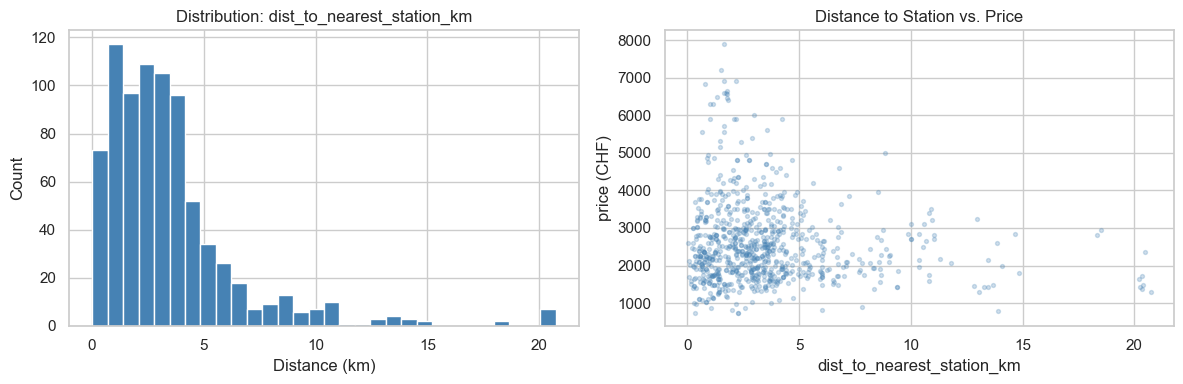

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["dist_to_nearest_station_km"].hist(bins=30, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Distribution: dist_to_nearest_station_km")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Count")

axes[1].scatter(df["dist_to_nearest_station_km"], df["price"], alpha=0.25, s=8, color="steelblue")
axes[1].set_xlabel("dist_to_nearest_station_km")
axes[1].set_ylabel("price (CHF)")
axes[1].set_title("Distance to Station vs. Price")

plt.tight_layout()
plt.show()

---
## 3. Iteration 1 — Baseline (13 Features)

**Objective:** Establish a performance baseline using the 13 existing engineered features with default model hyperparameters.

**Key changes vs. previous:** First iteration — no prior baseline.  

**Preprocessing:**
- `StandardScaler` on 9 continuous numeric features
- Passthrough (no scaling) for 4 binary/flag features
- 5-fold cross-validation

**Models:** `LinearRegression` (baseline), `RandomForestRegressor` (n_estimators=100, default params)

In [6]:
TARGET = "price"

NUMERIC_ITER1 = [
    "rooms", "area", "pop", "pop_dens", "frg_pct",
    "emp", "tax_income", "room_per_m2", "area_cat_ecoded"
]
BINARY_ITER1 = ["luxurious", "temporary", "furnished", "zurich_city"]
FEATURES_ITER1 = NUMERIC_ITER1 + BINARY_ITER1

X1 = df[FEATURES_ITER1]
y  = df[TARGET]

preprocessor_iter1 = ColumnTransformer(transformers=[
    ("scale", StandardScaler(), NUMERIC_ITER1),
    ("pass",  "passthrough",   BINARY_ITER1),
])

print(f"Iter1 feature count: {len(FEATURES_ITER1)}")
print(f"Training samples: {len(y)}")

Iter1 feature count: 13
Training samples: 802


In [7]:
def evaluate_model(pipeline, X, y, cv=5, label=""):
    """5-fold CV; returns (rmse_scores, r2_scores) and prints summary."""
    results = cross_validate(
        pipeline, X, y, cv=cv,
        scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"},
        return_train_score=True,
        n_jobs=-1,
    )
    train_rmse = -results["train_rmse"]
    train_r2   =  results["train_r2"]
    test_rmse  = -results["test_rmse"]
    test_r2    =  results["test_r2"]
    print(f"[{label}]")
    print(f"  Train RMSE: {train_rmse.mean():.1f} ± {train_rmse.std():.1f} CHF  |  Train R²: {train_r2.mean():.4f} ± {train_r2.std():.4f}")
    print(f"  Test  RMSE: {test_rmse.mean():.1f} ± {test_rmse.std():.1f} CHF  |  Test  R²: {test_r2.mean():.4f} ± {test_r2.std():.4f}")
    return test_rmse, test_r2

In [8]:
pipe_lr = Pipeline([
    ("pre",   preprocessor_iter1),
    ("model", LinearRegression()),
])

rmse_lr, r2_lr = evaluate_model(pipe_lr, X1, y, label="Iter1 — LinearRegression")

[Iter1 — LinearRegression]
  Train RMSE: 651.6 ± 53.0 CHF  |  Train R²: 0.6276 ± 0.0360
  Test  RMSE: 690.6 ± 173.4 CHF  |  Test  R²: 0.5055 ± 0.1035


In [9]:
pipe_rf1 = Pipeline([
    ("pre",   preprocessor_iter1),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42)),
])

rmse_rf1, r2_rf1 = evaluate_model(pipe_rf1, X1, y, label="Iter1 — RandomForest (default)")

[Iter1 — RandomForest (default)]
  Train RMSE: 246.1 ± 16.5 CHF  |  Train R²: 0.9469 ± 0.0041
  Test  RMSE: 716.5 ± 205.5 CHF  |  Test  R²: 0.4887 ± 0.0450


In [ ]:
iter1_summary = pd.DataFrame({
    "Model":         ["LinearRegression",    "RandomForest (n=100)"],
    "CV RMSE (CHF)": [rmse_lr.mean(),        rmse_rf1.mean()],
    "RMSE Std":      [rmse_lr.std(),         rmse_rf1.std()],
    "CV R²":         [r2_lr.mean(),          r2_rf1.mean()],
    "R² Std":        [r2_lr.std(),           r2_rf1.std()],
})

iter1_summary.round(2)

,Model,CV RMSE (CHF),RMSE Std,CV R²,R² Std
0,LinearRegression,690.641,173.417,0.505,0.104
1,RandomForest (n=100),716.490,205.492,0.489,0.045


**Observation:**  
- `LinearRegression` underfits (moderate R², high RMSE) — the price relationship is non-linear.  
- `RandomForest` (default) shows clear **overfitting**: high train R² but considerably lower test R².  

→ **Iteration 2** addresses this by: (1) adding the new geospatial feature, and (2) tuning hyperparameters to reduce variance and by also trying a gradient boosting model (LightGBM).

---
## 4. Iteration 2 — Feature Engineering + Hyperparameter Tuning (14 Features)

**Objective:** Improve generalization by adding `dist_to_nearest_station_km` and applying `RandomizedSearchCV` tuning to both RandomForest and LightGBM.

**Key changes vs. Iteration 1:**
- Added `dist_to_nearest_station_km` (14th feature)
- RandomizedSearchCV hyperparameter tuning (20 iterations, 5-fold CV)
- Introduced LightGBM as second model (gradient boosting vs. bagging)

**Preprocessing:**  
Same as Iteration 1 + `dist_to_nearest_station_km` added to the scaled numeric group.

**Models:**
- `RandomForestRegressor` with tuned `n_estimators`, `max_depth`, `max_features`, `min_samples_leaf`, `min_samples_split`
- `LGBMRegressor` with tuned `n_estimators`, `learning_rate`, `max_depth`, `num_leaves`, `subsample`, `colsample_bytree`

In [11]:
NUMERIC_ITER2 = NUMERIC_ITER1 + ["dist_to_nearest_station_km"]
BINARY_ITER2  = BINARY_ITER1  # unchanged
FEATURES_ITER2 = NUMERIC_ITER2 + BINARY_ITER2

X2 = df[FEATURES_ITER2]

preprocessor_iter2 = ColumnTransformer(transformers=[
    ("scale", StandardScaler(), NUMERIC_ITER2),
    ("pass",  "passthrough",   BINARY_ITER2),
])

print(f"Iter2 feature count: {len(FEATURES_ITER2)}")

Iter2 feature count: 14


In [12]:
# ── Tuned RandomForest ────────────────────────────────────────────────────────
rf_param_dist = {
    "model__n_estimators":     [200, 300, 500],
    "model__max_depth":        [10, 20, 30, None],
    "model__max_features":     ["sqrt", "log2", 0.5],
    "model__min_samples_leaf": [2, 4, 6],
    "model__min_samples_split":[4, 8, 12],
}

pipe_rf2 = Pipeline([
    ("pre",   preprocessor_iter2),
    ("model", RandomForestRegressor(random_state=42)),
])

rf_search = RandomizedSearchCV(
    pipe_rf2, rf_param_dist,
    n_iter=20, cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42, verbose=1, n_jobs=-1,
)
rf_search.fit(X2, y)
print("\nBest RF hyperparameters:", rf_search.best_params_)
best_rf_pipe = rf_search.best_estimator_

rmse_rf2, r2_rf2 = evaluate_model(best_rf_pipe, X2, y, label="Iter2 — RF Tuned")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best RF hyperparameters: {'model__n_estimators': 500, 'model__min_samples_split': 4, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 20}
[Iter2 — RF Tuned]
  Train RMSE: 328.1 ± 21.6 CHF  |  Train R²: 0.9056 ± 0.0056
  Test  RMSE: 661.8 ± 198.1 CHF  |  Test  R²: 0.5658 ± 0.0503


In [13]:
# ── Tuned LightGBM ────────────────────────────────────────────────────────────
lgb_param_dist = {
    "model__n_estimators":      [200, 400, 600],
    "model__learning_rate":     [0.01, 0.05, 0.1],
    "model__max_depth":         [4, 6, 8, -1],
    "model__num_leaves":        [15, 31, 63],
    "model__subsample":         [0.7, 0.8, 1.0],
    "model__colsample_bytree":  [0.7, 0.8, 1.0],
}

pipe_lgb = Pipeline([
    ("pre",   preprocessor_iter2),
    ("model", lgb.LGBMRegressor(random_state=42, verbose=-1)),
])

lgb_search = RandomizedSearchCV(
    pipe_lgb, lgb_param_dist,
    n_iter=20, cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42, verbose=1, n_jobs=-1,
)
lgb_search.fit(X2, y)
print("\nBest LGB hyperparameters:", lgb_search.best_params_)
best_lgb_pipe = lgb_search.best_estimator_

rmse_lgb, r2_lgb = evaluate_model(best_lgb_pipe, X2, y, label="Iter2 — LightGBM Tuned")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best LGB hyperparameters: {'model__subsample': 0.8, 'model__num_leaves': 63, 'model__n_estimators': 400, 'model__max_depth': 8, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
[Iter2 — LightGBM Tuned]
  Train RMSE: 446.3 ± 30.1 CHF  |  Train R²: 0.8254 ± 0.0111
  Test  RMSE: 668.9 ± 208.6 CHF  |  Test  R²: 0.5595 ± 0.0546


In [14]:
iter2_summary = pd.DataFrame({
    "Model":         ["RF Tuned",    "LightGBM Tuned"],
    "CV RMSE (CHF)": [rmse_rf2.mean(),  rmse_lgb.mean()],
    "RMSE Std":      [rmse_rf2.std(),   rmse_lgb.std()],
    "CV R²":         [r2_rf2.mean(),    r2_lgb.mean()],
    "R² Std":        [r2_rf2.std(),     r2_lgb.std()],
})

iter2_summary.round(3)

,Model,CV RMSE (CHF),RMSE Std,CV R²,R² Std
0,RF Tuned,661.803,198.061,0.566,0.050
1,LightGBM Tuned,668.869,208.620,0.559,0.055


Selected model: RandomForest (lower CV RMSE)


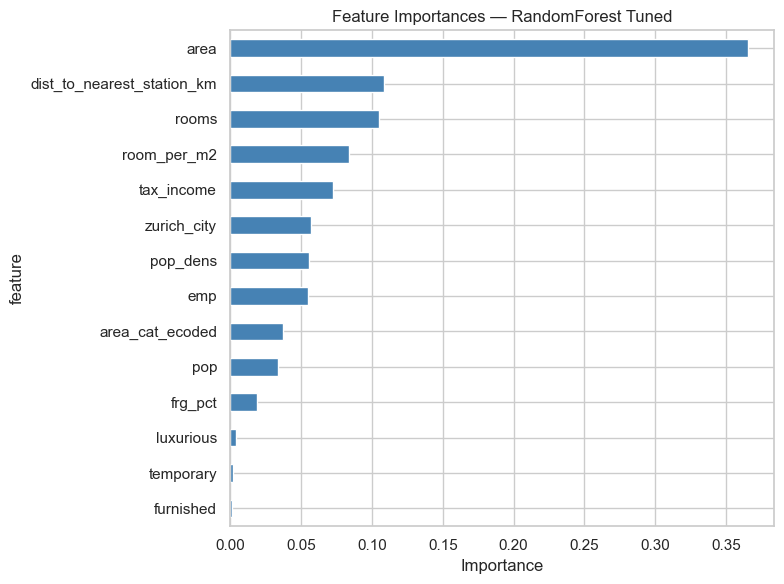

In [15]:
# ── Feature importance for best iteration-2 model ────────────────────────────
# Pick the model with lower CV RMSE as the final model
if rmse_lgb.mean() <= rmse_rf2.mean():
    final_pipe = best_lgb_pipe
    final_label = "LightGBM Tuned"
    print("Selected model: LightGBM (lower CV RMSE)")
else:
    final_pipe = best_rf_pipe
    final_label = "RandomForest Tuned"
    print("Selected model: RandomForest (lower CV RMSE)")

# Fit on full data for feature importance extraction
final_pipe.fit(X2, y)

feat_names   = NUMERIC_ITER2 + BINARY_ITER2
importances  = final_pipe.named_steps["model"].feature_importances_

df_fi = pd.DataFrame({"feature": feat_names, "importance": importances})
df_fi = df_fi.sort_values("importance")

df_fi.plot(kind="barh", x="feature", y="importance",
           figsize=(8, 6), legend=False, color="steelblue")
plt.title(f"Feature Importances — {final_label}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

---
## 5. Overall Comparison

In [16]:
# Best models per iteration
best_r2_iter1 = max(r2_lr.mean(), r2_rf1.mean())
best_r2_iter2 = max(r2_rf2.mean(), r2_lgb.mean())
best_rmse_iter1 = min(rmse_lr.mean(), rmse_rf1.mean())
best_rmse_iter2 = min(rmse_rf2.mean(), rmse_lgb.mean())

comparison = pd.DataFrame({
    "Iteration":         ["Iter 1 (best)",          "Iter 2 (best)"],
    "Best CV RMSE (CHF)":[best_rmse_iter1,           best_rmse_iter2],
    "Best CV R²":        [best_r2_iter1,             best_r2_iter2],
    "Delta R²":          ["-",  f"+{best_r2_iter2 - best_r2_iter1:.4f}"],
})
comparison

,Iteration,Best CV RMSE (CHF),Best CV R²,Delta R²
0,Iter 1 (best),690.640734,0.505486,-
1,Iter 2 (best),661.803004,0.565821,+0.0603


---
## 6. Model Serialization

Save the complete inference artifact to `model.pkl`:
- `pipeline`: fitted sklearn Pipeline (preprocessor + best model)
- `feature_names`: ordered list of 14 features the pipeline expects
- `median_defaults`: median values for features not exposed in the Gradio app
- `training_rmse` / `training_r2`: CV metrics for display

In [17]:
# Determine final CV metrics based on which model was selected
if final_label.startswith("LightGBM"):
    final_rmse_cv = rmse_lgb
    final_r2_cv   = r2_lgb
else:
    final_rmse_cv = rmse_rf2
    final_r2_cv   = r2_rf2

# Median defaults for features not exposed in the Gradio app
# (room_per_m2 and area_cat_ecoded are recomputed at inference from rooms/area)
HIDDEN_FEATURES = [
    "pop", "pop_dens", "frg_pct", "emp", "tax_income",
    "room_per_m2", "area_cat_ecoded",
    "luxurious", "furnished", "zurich_city",
]
median_defaults = {col: float(df[col].median()) for col in HIDDEN_FEATURES}

print("Median defaults for hidden features:")
for k, v in median_defaults.items():
    print(f"  {k}: {v}")

Median defaults for hidden features:
  pop: 24990.0
  pop_dens: 1662.5973262818
  frg_pct: 28.8658429348
  emp: 19226.0
  tax_income: 80977.0
  room_per_m2: 24.67
  area_cat_ecoded: 2.0
  luxurious: 0.0
  furnished: 0.0
  zurich_city: 0.0


In [18]:
model_artifact = {
    "pipeline":       final_pipe,
    "feature_names":  FEATURES_ITER2,
    "median_defaults": median_defaults,
    "training_rmse":  float(final_rmse_cv.mean()),
    "training_r2":    float(final_r2_cv.mean()),
}

with open("model.pkl", "wb") as f:
    pickle.dump(model_artifact, f)

print(f"Saved model.pkl")
print(f"  Model: {final_label}")
print(f"  CV RMSE: {final_rmse_cv.mean():.1f} CHF")
print(f"  CV R²:   {final_r2_cv.mean():.4f}")

Saved model.pkl
  Model: RandomForest Tuned
  CV RMSE: 661.8 CHF
  CV R²:   0.5658


In [19]:
# ── Round-trip verification ───────────────────────────────────────────────────
with open("model.pkl", "rb") as f:
    loaded = pickle.load(f)

row = dict(loaded["median_defaults"])
row["rooms"]                      = 3.5
row["area"]                       = 80.0
row["temporary"]                  = 0
row["dist_to_nearest_station_km"] = 1.0
row["room_per_m2"]                = round(80.0 / 3.5, 4)
row["area_cat_ecoded"]            = 1.0  # 50-99 m²

X_test = pd.DataFrame([row])[loaded["feature_names"]]
pred   = loaded["pipeline"].predict(X_test)[0]

print(f"Verification — 3.5 rooms, 80 m², not temp, 1.0 km to station:")
print(f"  Predicted price: CHF {pred:,.0f} / month")
assert 700 < pred < 10000, f"Prediction {pred:.0f} outside plausible range!"
print("  Assertion passed — prediction in plausible range.")

Verification — 3.5 rooms, 80 m², not temp, 1.0 km to station:
  Predicted price: CHF 2,180 / month
  Assertion passed — prediction in plausible range.


---
## 7. README Metrics Summary

Copy the output of the next cell into `README.md` to fill in the iteration table.

In [20]:
best_iter1_name = "RandomForest" if r2_rf1.mean() > r2_lr.mean() else "LinearRegression"
best_iter1_rmse = min(rmse_lr.mean(), rmse_rf1.mean())
best_iter1_r2   = max(r2_lr.mean(), r2_rf1.mean())
best_iter1_std  = (r2_rf1 if r2_rf1.mean() > r2_lr.mean() else r2_lr).std()

delta = best_r2_iter2 - best_r2_iter1

print("=" * 80)
print("README ITERATION TABLE ROWS (copy into README.md)")
print("=" * 80)
print()
print("Iteration 1 — best model results:")
print(f"  LinearRegression: RMSE={rmse_lr.mean():.1f} CHF, R²={r2_lr.mean():.4f} ± {r2_lr.std():.4f}")
print(f"  RandomForest:     RMSE={rmse_rf1.mean():.1f} CHF, R²={r2_rf1.mean():.4f} ± {r2_rf1.std():.4f}")
print()
print("Iteration 2 — best model results:")
print(f"  RF Tuned:         RMSE={rmse_rf2.mean():.1f} CHF, R²={r2_rf2.mean():.4f} ± {r2_rf2.std():.4f}")
print(f"  LightGBM Tuned:   RMSE={rmse_lgb.mean():.1f} CHF, R²={r2_lgb.mean():.4f} ± {r2_lgb.std():.4f}")
print()
print(f"Improvement (best iter1 → best iter2): ΔR² = +{delta:.4f}")
print("=" * 80)

README ITERATION TABLE ROWS (copy into README.md)

Iteration 1 — best model results:
  LinearRegression: RMSE=690.6 CHF, R²=0.5055 ± 0.1035
  RandomForest:     RMSE=716.5 CHF, R²=0.4887 ± 0.0450

Iteration 2 — best model results:
  RF Tuned:         RMSE=661.8 CHF, R²=0.5658 ± 0.0503
  LightGBM Tuned:   RMSE=668.9 CHF, R²=0.5595 ± 0.0546

Improvement (best iter1 → best iter2): ΔR² = +0.0603
